# Deep data inspection — IP-pair flow grouping (sequence-analysis feasibility)

Single-flow classification treats every flow as an independent object. Before investing in
**sequence analysis** (classifying *groups* of related flows, or subsets of a group, as a sequence)
we need to know whether such groups actually exist in the data.

**Grouping rule:** flows are grouped by the **unordered IP pair** `{src_ip, dst_ip}`. The 5-tuple's
`src`/`dst` only encode *who initiated* the connection, so `A->B` and `B->A` are placed in the
**same** group (the key is `min(ip) <-> max(ip)`).

We compute the distribution of **group sizes** (flows per IP-pair group) for **each malware type**
and the **benign** class, in both the **train** and **test** splits of the custom
`icsx-ctu-extended` dataset.

If most groups contain only 1-2 flows, sequence analysis buys us little; the key deliverable is the
**flow-coverage curve**: *what fraction of flows live in groups of size >= k*.

In [1]:
import os, sys, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# --- configuration ---
DATASET = 'icsx-ctu-extended'   # custom dataset: icsx-botnet-2014 + ctu-13 + ctu-custom
SPLITS = ['train', 'test']
MIN_PACKETS = 3                 # match the classifier's packets_count >= 3 filter; set to 0 to keep all flows
BASE = os.path.join('..', 'flows')
print(f'dataset={DATASET}  splits={SPLITS}  min_packets={MIN_PACKETS}')

dataset=icsx-ctu-extended  splits=['train', 'test']  min_packets=3


In [2]:
# --- loaders & grouping helpers ---

def ip_pair_key(df):
    """Order-independent IP-pair key: 'min_ip <-> max_ip' (initiator-agnostic)."""
    a = df['src_ip'].astype(str)
    b = df['dst_ip'].astype(str)
    lo = a.where(a <= b, b)   # min of the two IPs (as strings)
    hi = b.where(a <= b, a)   # max of the two IPs
    return lo.str.cat(hi, sep=' <-> ')

def load_class(split, kind, subclass=None):
    """Load one class (benign, or a malicious subclass) for a split.
    Only the columns needed for grouping are read to keep memory low."""
    parts = [BASE, split, DATASET, kind] + ([subclass] if subclass else [])
    path = os.path.join(*parts)
    df = pd.read_parquet(path, columns=['src_ip', 'dst_ip', 'packets_count'])
    if MIN_PACKETS:
        df = df[df['packets_count'] >= MIN_PACKETS]
    return df

def discover_subclasses(split):
    mpath = os.path.join(BASE, split, DATASET, 'malicious')
    return sorted(os.path.basename(p) for p in glob.glob(os.path.join(mpath, '*')) if os.path.isdir(p))

def group_sizes(df):
    """Series indexed by IP-pair key -> number of flows in that group."""
    return df.groupby(ip_pair_key(df)).size()

In [3]:
# --- build {split: {class_name: group_size_series}} ---
group_data = {}
for split in SPLITS:
    group_data[split] = {}
    benign = load_class(split, 'benign')
    if not benign.empty:
        group_data[split]['benign'] = group_sizes(benign)
    for sc in discover_subclasses(split):
        df = load_class(split, 'malicious', sc)
        if not df.empty:
            group_data[split][sc] = group_sizes(df)
    print(f"{split}: loaded {len(group_data[split])} classes -> {list(group_data[split].keys())}")

train: loaded 10 classes -> ['benign', 'Emotet', 'IRC', 'Kazy', 'Neris', 'RBot', 'TrickBot', 'Virut', 'WannaCry', 'Zeus']

test: loaded 16 classes -> ['benign', 'DonBot', 'Emotet', 'IRC', 'Kazy', 'Menti', 'Murlo', 'NSIS.ay', 'Neris', 'RBot', 'Sogou', 'TrickBot', 'Virut', 'WannaCry', 'Weasel', 'Zeus']


In [4]:
# --- per-class summary statistics ---

def summarize(sizes):
    n_groups = len(sizes)
    n_flows = int(sizes.sum())
    singleton = int((sizes == 1).sum())   # groups with exactly one flow
    return {
        'flows': n_flows,
        'groups': n_groups,
        'singleton_groups': singleton,
        # fraction of GROUPS that are singletons
        'singleton_group_ratio': singleton / n_groups if n_groups else np.nan,
        # fraction of FLOWS that sit alone (a singleton group holds exactly 1 flow)
        'flows_in_singletons_ratio': singleton / n_flows if n_flows else np.nan,
        'avg_flows_per_group': n_flows / n_groups if n_groups else np.nan,
        'median_group_size': float(sizes.median()) if n_groups else np.nan,
        'p90_group_size': float(sizes.quantile(0.90)) if n_groups else np.nan,
        'p99_group_size': float(sizes.quantile(0.99)) if n_groups else np.nan,
        'max_group_size': int(sizes.max()) if n_groups else 0,
        'groups_ge_2': int((sizes >= 2).sum()),
        'groups_ge_5': int((sizes >= 5).sum()),
        'groups_ge_10': int((sizes >= 10).sum()),
        # fraction of FLOWS that live in a group big enough for sequence analysis
        'flows_in_groups_ge_2_ratio': int(sizes[sizes >= 2].sum()) / n_flows if n_flows else np.nan,
        'flows_in_groups_ge_5_ratio': int(sizes[sizes >= 5].sum()) / n_flows if n_flows else np.nan,
    }

summary = {}
for split in SPLITS:
    rows = {cls: summarize(s) for cls, s in group_data[split].items()}
    sdf = pd.DataFrame(rows).T
    summary[split] = sdf
    print(f"\n=== {split.upper()} - group-size summary (unordered IP pair, packets_count >= {MIN_PACKETS}) ===")
    display(sdf.round(3))


=== TRAIN - group-size summary (unordered IP pair, packets_count >= 3) ===


,flows,groups,singleton_groups,singleton_group_ratio,flows_in_singletons_ratio,avg_flows_per_group,median_group_size,p90_group_size,p99_group_size,max_group_size,groups_ge_2,groups_ge_5,groups_ge_10,flows_in_groups_ge_2_ratio,flows_in_groups_ge_5_ratio
benign,139178.0,13263.0,5610.0,0.423,0.040,10.494,2.0,15.0,130.00,5771.0,7653.0,3544.0,2026.0,0.960,0.880
Emotet,32019.0,49.0,1.0,0.020,0.000,653.449,580.0,1111.0,1112.00,1112.0,48.0,48.0,48.0,1.000,1.000
IRC,2439.0,7.0,0.0,0.000,0.000,348.429,298.0,546.4,649.54,661.0,7.0,7.0,7.0,1.000,1.000
Kazy,4991.0,43.0,30.0,0.698,0.006,116.070,1.0,77.0,2298.38,2345.0,13.0,7.0,6.0,0.994,0.991
Neris,12020.0,2047.0,1171.0,0.572,0.097,5.872,1.0,6.0,77.78,963.0,876.0,308.0,132.0,0.903,0.779
RBot,32324.0,28806.0,28644.0,0.994,0.886,1.122,1.0,1.0,1.00,2018.0,162.0,10.0,9.0,0.114,0.104
TrickBot,19999.0,40.0,7.0,0.175,0.000,499.975,464.5,1129.9,1455.38,1556.0,33.0,30.0,29.0,1.000,0.999
Virut,850.0,180.0,130.0,0.722,0.153,4.722,1.0,6.0,54.60,275.0,50.0,22.0,11.0,0.847,0.771
WannaCry,5744.0,2764.0,1608.0,0.582,0.280,2.078,1.0,3.0,4.00,246.0,1156.0,8.0,6.0,0.720,0.138
Zeus,40000.0,5.0,0.0,0.000,0.000,8000.000,5564.0,17568.8,20394.08,20708.0,5.0,5.0,5.0,1.000,1.000



=== TEST - group-size summary (unordered IP pair, packets_count >= 3) ===


,flows,groups,singleton_groups,singleton_group_ratio,flows_in_singletons_ratio,avg_flows_per_group,median_group_size,p90_group_size,p99_group_size,max_group_size,groups_ge_2,groups_ge_5,groups_ge_10,flows_in_groups_ge_2_ratio,flows_in_groups_ge_5_ratio
benign,46477.0,8208.0,4286.0,0.522,0.092,5.662,1.0,9.0,70.00,645.0,3922.0,1623.0,803.0,0.908,0.782
DonBot,2747.0,845.0,632.0,0.748,0.230,3.251,1.0,3.0,46.00,197.0,213.0,69.0,47.0,0.770,0.644
Emotet,148905.0,94.0,2.0,0.021,0.000,1584.096,1649.0,2334.0,2699.63,2708.0,92.0,91.0,91.0,1.000,1.000
IRC,250.0,7.0,0.0,0.000,0.000,35.714,33.0,56.8,68.68,70.0,7.0,6.0,6.0,1.000,0.988
Kazy,11916.0,129.0,43.0,0.333,0.004,92.372,2.0,226.6,1023.32,4105.0,86.0,42.0,30.0,0.996,0.987
Menti,2747.0,845.0,632.0,0.748,0.230,3.251,1.0,3.0,46.00,197.0,213.0,69.0,47.0,0.770,0.644
Murlo,5185.0,130.0,58.0,0.446,0.011,39.885,3.0,29.0,865.67,1063.0,72.0,56.0,54.0,0.989,0.979
NSIS.ay,370.0,150.0,60.0,0.400,0.162,2.467,2.0,6.0,8.00,8.0,90.0,23.0,0.0,0.838,0.378
Neris,103917.0,17236.0,10621.0,0.616,0.102,6.029,1.0,6.0,64.00,2909.0,6615.0,2149.0,1164.0,0.898,0.791
RBot,32643.0,28817.0,28635.0,0.994,0.877,1.133,1.0,1.0,1.00,2018.0,182.0,11.0,10.0,0.123,0.112


## Flow-coverage curve (the key feasibility chart)

For each class: *what fraction of all its flows live in IP-pair groups of size >= k?*
A class whose curve stays high as `k` grows has many flows embedded in large groups — good
candidates for sequence analysis. A class that collapses toward 0 right after `k=1` is dominated
by isolated flows, where grouping adds little.

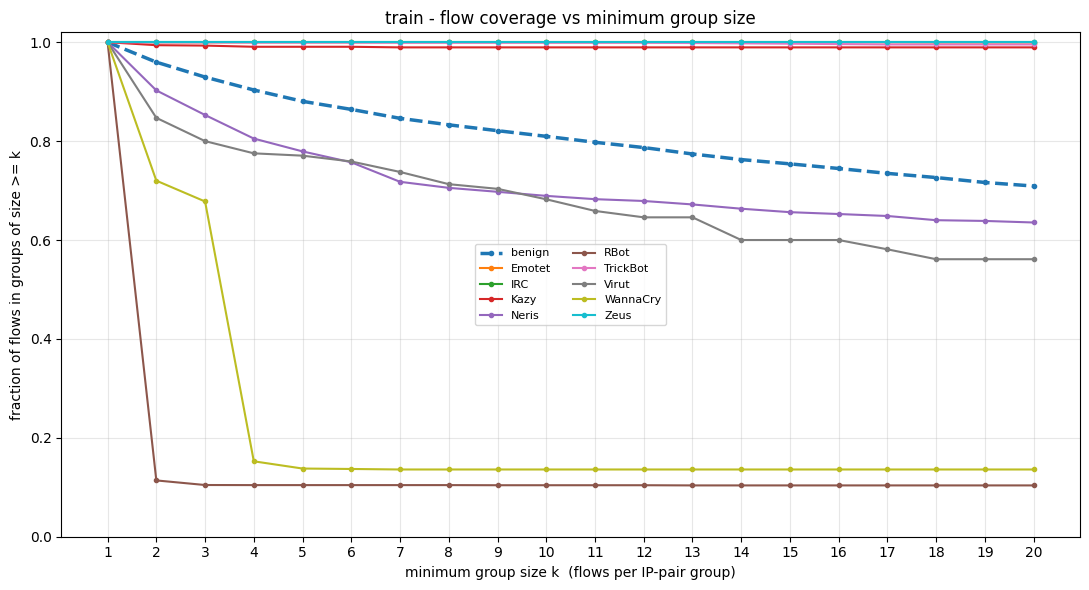

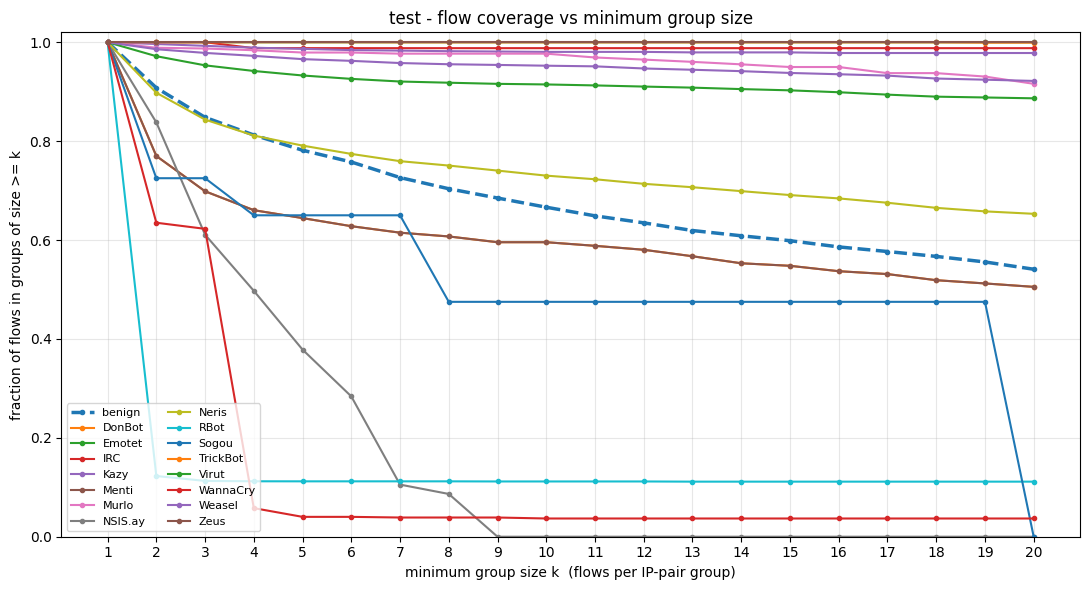

In [5]:
def coverage_curve(sizes, ks):
    total = sizes.sum()
    return [sizes[sizes >= k].sum() / total for k in ks]

ks = list(range(1, 21))
for split in SPLITS:
    plt.figure(figsize=(11, 6))
    for cls, s in group_data[split].items():
        style = '--' if cls == 'benign' else '-'
        lw = 2.5 if cls == 'benign' else 1.5
        plt.plot(ks, coverage_curve(s, ks), marker='o', ms=3, ls=style, lw=lw, label=cls)
    plt.xlabel('minimum group size k  (flows per IP-pair group)')
    plt.ylabel('fraction of flows in groups of size >= k')
    plt.title(f'{split} - flow coverage vs minimum group size')
    plt.ylim(0, 1.02)
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## Group-size distribution histograms (per class)

Log-log histograms of group sizes. A spike at 1 with a fast-decaying tail means mostly singletons;
a heavy tail means substantial multi-flow structure to exploit.

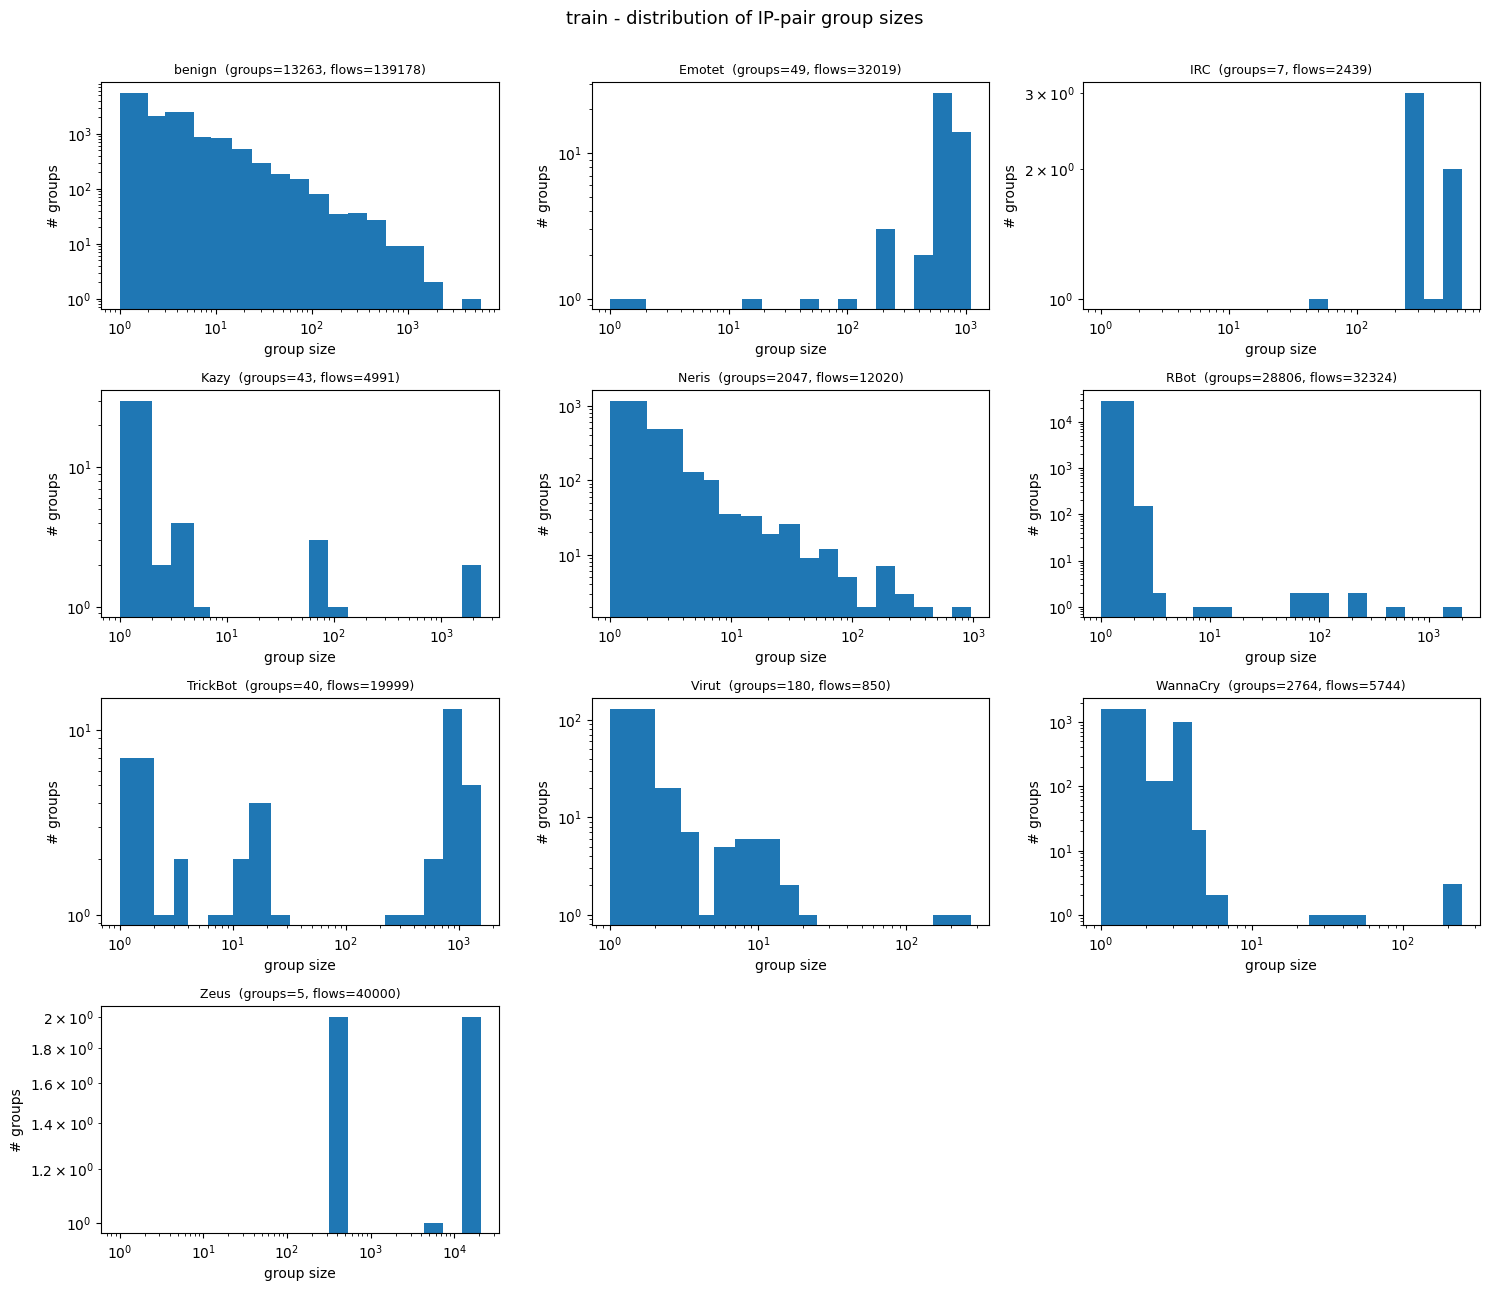

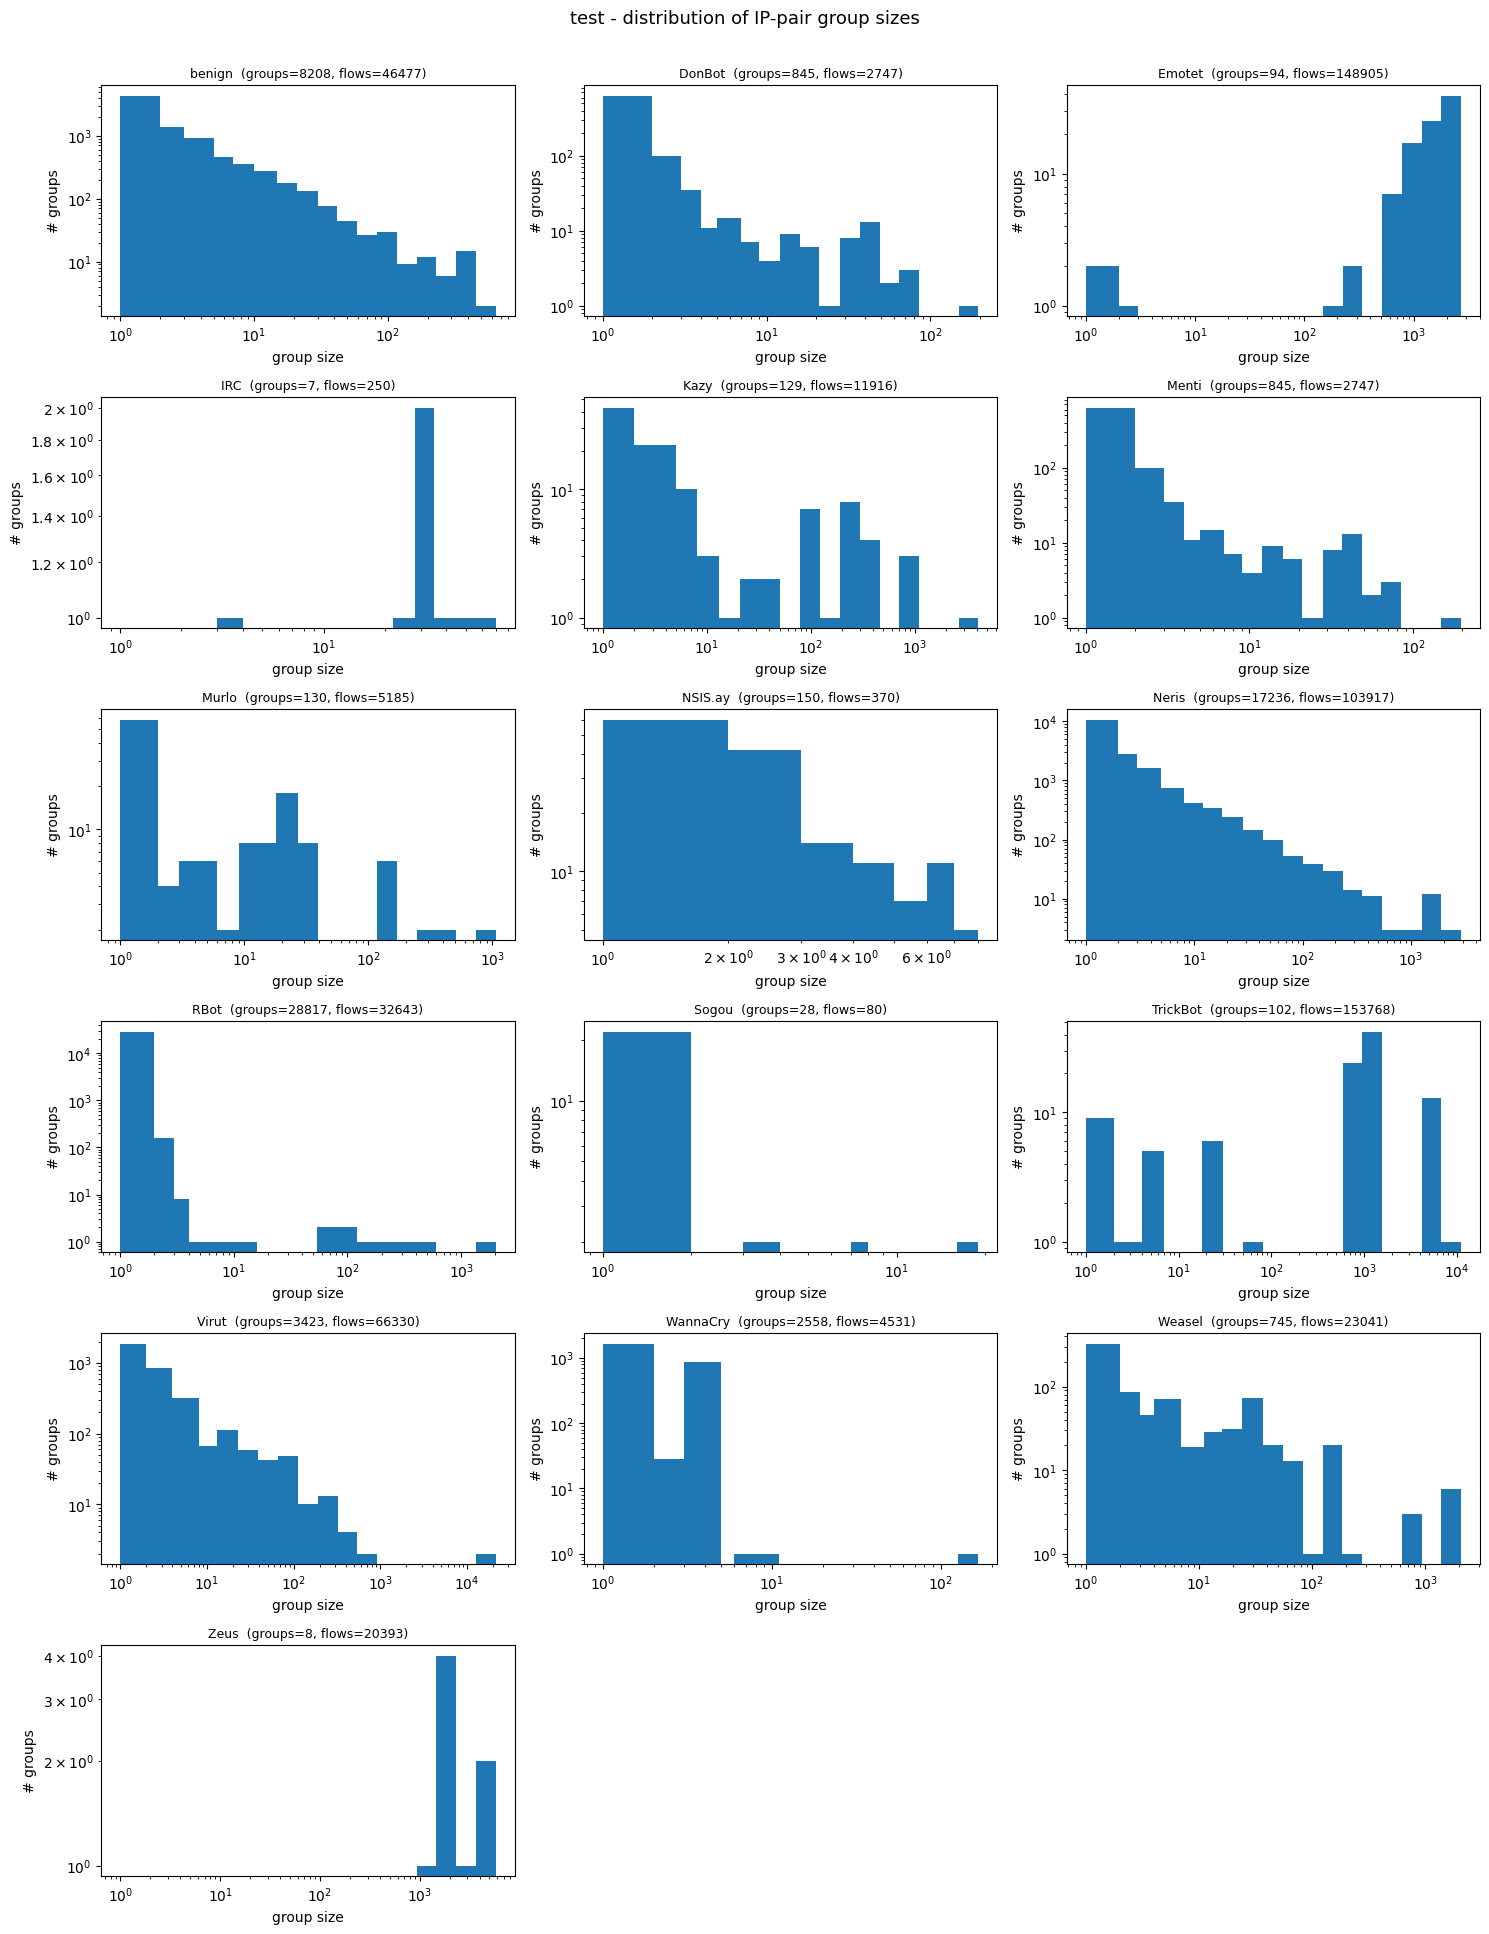

In [6]:
def plot_hist_grid(split):
    classes = list(group_data[split].items())
    ncols = 3
    nrows = math.ceil(len(classes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, (cls, s) in zip(axes, classes):
        maxv = max(2, int(s.max()))
        bins = np.unique(np.geomspace(1, maxv, num=20).astype(int))
        if len(bins) < 2:
            bins = [1, 2]
        ax.hist(s.values, bins=bins)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(f'{cls}  (groups={len(s)}, flows={int(s.sum())})', fontsize=9)
        ax.set_xlabel('group size'); ax.set_ylabel('# groups')
    for ax in axes[len(classes):]:
        ax.axis('off')
    fig.suptitle(f'{split} - distribution of IP-pair group sizes', y=1.005, fontsize=13)
    fig.tight_layout()
    plt.show()

for split in SPLITS:
    plot_hist_grid(split)

## Cross-class comparison

Side-by-side view: average flows per group (higher = more sequence structure) vs the fraction of
flows that are isolated singletons (higher = less benefit from grouping).

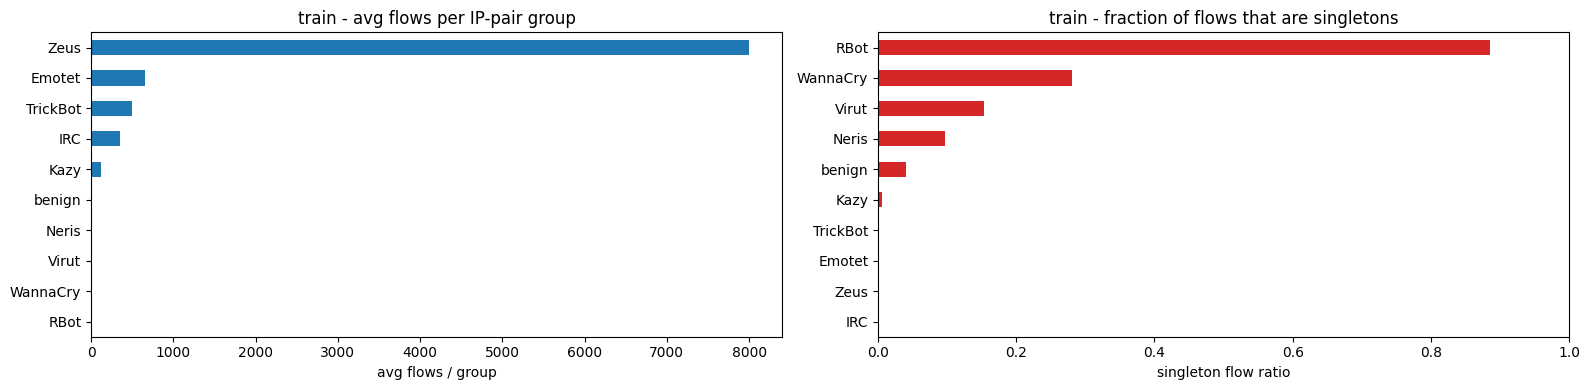

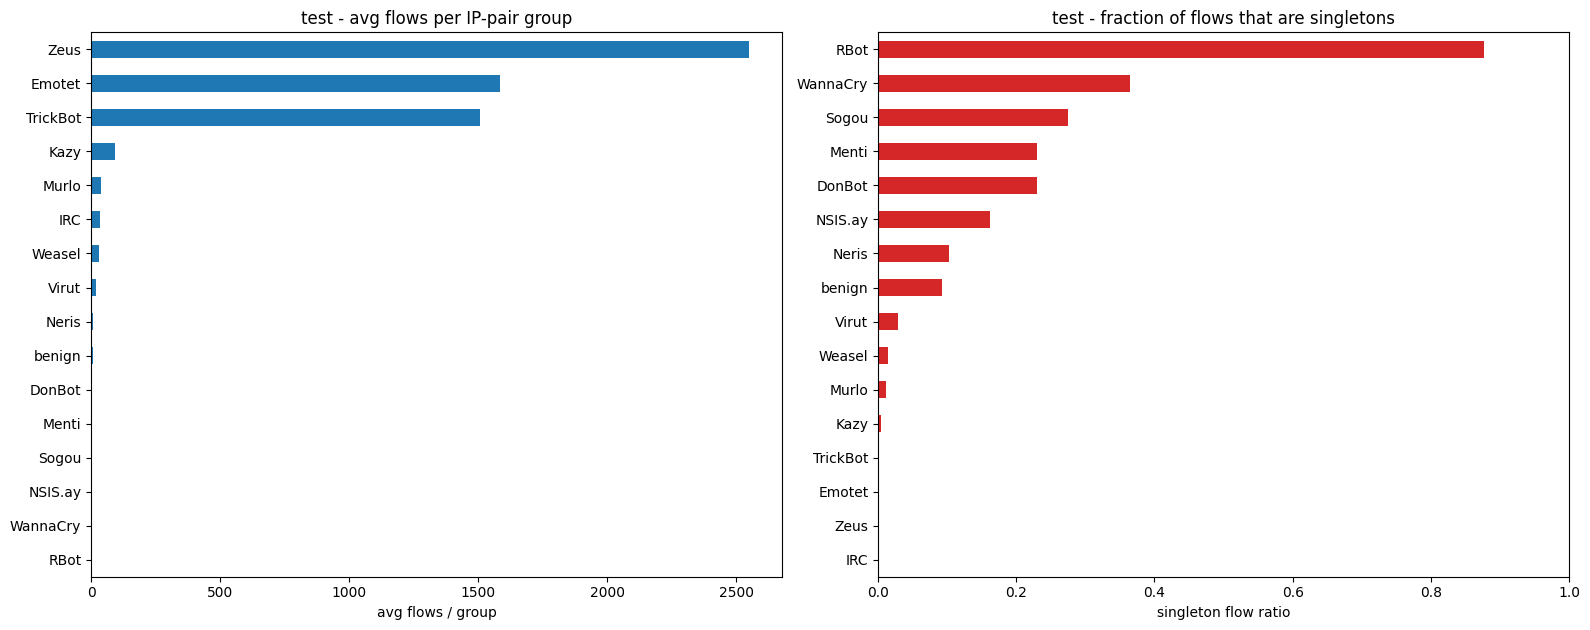

In [7]:
for split in SPLITS:
    sdf = summary[split]
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 0.4 * len(sdf))))
    sdf['avg_flows_per_group'].sort_values().plot.barh(
        ax=axes[0], color='tab:blue', title=f'{split} - avg flows per IP-pair group')
    axes[0].set_xlabel('avg flows / group')
    sdf['flows_in_singletons_ratio'].sort_values().plot.barh(
        ax=axes[1], color='tab:red', title=f'{split} - fraction of flows that are singletons')
    axes[1].set_xlabel('singleton flow ratio'); axes[1].set_xlim(0, 1)
    fig.tight_layout()
    plt.show()

## Notes & possible extensions

- **Grouping scope.** Group sizes are computed *within each class* (per malware subclass / benign).
  This answers "per malware type" directly; flows are not mixed across classes.
- **Key choice.** Only the unordered IP pair is used. To make groups stricter (and typically smaller)
  you could add `protocol` or the server-side port to the key.
- **Packet filter.** `MIN_PACKETS=3` mirrors the classifier. Set it to `0` and re-run to see the
  distribution over *all* reconstructed flows.
- **Intra-flow sequences.** The other sequence-analysis avenue is the per-flow `payload_bytes_seq` /
  `interarrival_time_s_seq` lists already stored during reconstruction (see `flow_features.py`),
  which don't depend on group sizes at all.